In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
# ==========================================
# PART A: RE-RUNNING PREPROCESSING (PHASE 2)
# ==========================================
print(">>> PART A: Preparing Data ...")

# 1. Load Data
train = pd.read_csv('train.csv', parse_dates=['Date'], low_memory=False)
store = pd.read_csv('store.csv')

# 2. Merge & Filter
df = pd.merge(train, store, on='Store', how='left')
df = df[(df['Open'] == 1) & (df['Sales'] > 0)].copy()
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

# 3. Date Features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

# 4. Competition Open Time
df['CompetitionOpenSince'] = pd.to_datetime(dict(year=df.CompetitionOpenSinceYear.fillna(1900), 
                                                 month=df.CompetitionOpenSinceMonth.fillna(1), day=1))
df['CompetitionDaysOpen'] = (df['Date'] - df['CompetitionOpenSince']).dt.days
df['CompetitionDaysOpen'] = df['CompetitionDaysOpen'].apply(lambda x: x if x > 0 else 0)

# 5. Lag & Rolling Features (Simplified for speed)
grouped = df.groupby('Store')['Sales']
df['Sales_Lag1'] = grouped.shift(1)
df['Sales_Lag7'] = grouped.shift(7)
df['Sales_RollMean7'] = grouped.shift(1).rolling(window=7).mean()
df.dropna(subset=['Sales_Lag1', 'Sales_Lag7', 'Sales_RollMean7'], inplace=True)

# 6. Encoding & FillNA
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())
df['PromoInterval'] = df['PromoInterval'].fillna('None')

df = df.fillna(0) 

categorical_cols = ['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval'] 
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

# 7. Split Data (Time-based)
# Last 6 weeks for Test, Previous 6 weeks for Val
max_date = df['Date'].max()
test_cutoff = max_date - pd.Timedelta(days=6*7)
val_cutoff = test_cutoff - pd.Timedelta(days=6*7)

train_df = df[df['Date'] < val_cutoff]
val_df   = df[(df['Date'] >= val_cutoff) & (df['Date'] < test_cutoff)]
test_df  = df[df['Date'] >= test_cutoff]

# Define Features & Target
target = 'Sales'
ignore_cols = ['Date', 'Customers', 'Open', 'CompetitionOpenSince', 
               'CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth']
features = [c for c in df.columns if c not in ignore_cols + [target]]

X_train, y_train = train_df[features], train_df[target]
X_val, y_val     = val_df[features], val_df[target]
X_test, y_test   = test_df[features], test_df[target]

print(f"Data Prepared. Train shape: {X_train.shape}, Test shape: {X_test.shape}\n")



>>> PART A: Preparing Data ...
Data Prepared. Train shape: (745322, 21), Test shape: (41415, 21)



In [7]:
# ==========================================
# PART B: MODELING & EVALUATION (PHASE 3)
# ==========================================
print(">>> PART B: Phase 3 Modeling Started...")

def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


>>> PART B: Phase 3 Modeling Started...


In [8]:
# ------------------------------------------
# 1. Baseline Model (Linear Regression)
# ------------------------------------------
print("\n[1] Training Baseline (Linear Regression)...")

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict & Evaluate
y_pred_lr = lr_model.predict(X_test)
rmse_lr = calculate_rmse(y_test, y_pred_lr)

print(f"   -> Baseline RMSE: {rmse_lr:.4f}")



[1] Training Baseline (Linear Regression)...
   -> Baseline RMSE: 1534.5094


In [9]:
# ------------------------------------------
# 2. Advanced Model (XGBoost)
# ------------------------------------------
print("\n[2] Training Advanced Model (XGBoost)...")

xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=50
)

# Train with Eval Set
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

# Predict & Evaluate
y_pred_xgb = xgb_model.predict(X_test)
rmse_xgb = calculate_rmse(y_test, y_pred_xgb)

print(f"\n   -> XGBoost RMSE: {rmse_xgb:.4f}")
print(f"   -> Improvement: {rmse_lr - rmse_xgb:.4f} (Sales units)")




[2] Training Advanced Model (XGBoost)...
[0]	validation_0-rmse:2979.21352	validation_1-rmse:3106.04890
[100]	validation_0-rmse:838.59599	validation_1-rmse:1092.81761
[200]	validation_0-rmse:740.41307	validation_1-rmse:1049.18594
[300]	validation_0-rmse:679.26519	validation_1-rmse:1024.45239
[400]	validation_0-rmse:633.44310	validation_1-rmse:1003.12527
[500]	validation_0-rmse:597.28887	validation_1-rmse:990.77213
[600]	validation_0-rmse:572.43451	validation_1-rmse:983.92375
[700]	validation_0-rmse:549.90006	validation_1-rmse:978.76589
[800]	validation_0-rmse:528.94667	validation_1-rmse:973.26868
[900]	validation_0-rmse:511.66791	validation_1-rmse:970.43164
[999]	validation_0-rmse:496.23114	validation_1-rmse:968.96206

   -> XGBoost RMSE: 879.6774
   -> Improvement: 654.8320 (Sales units)



[3] Generating SHAP Feature Importance...


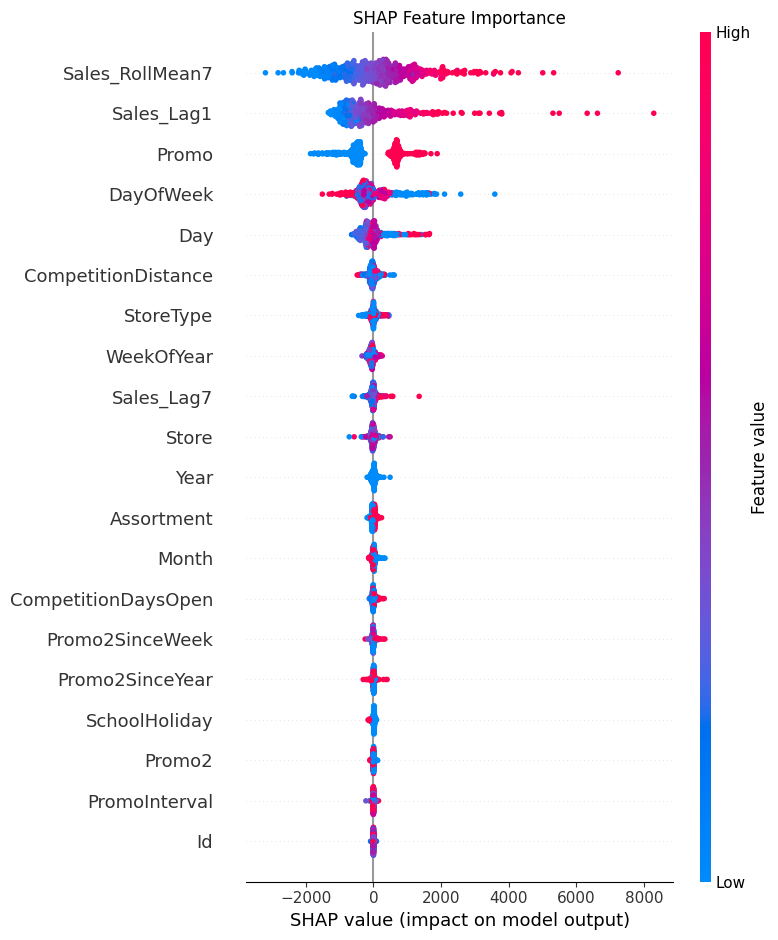

In [10]:
# ------------------------------------------
# 3. Feature Importance (SHAP)
# ------------------------------------------
print("\n[3] Generating SHAP Feature Importance...")

# Use a small sample for speed
shap_sample = X_test.sample(n=500, random_state=42)
explainer = shap.Explainer(xgb_model)
shap_values = explainer(shap_sample)

# Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.savefig("SHAP_Importance.png") # Save plot
plt.show()




[4] Performing Error Analysis...


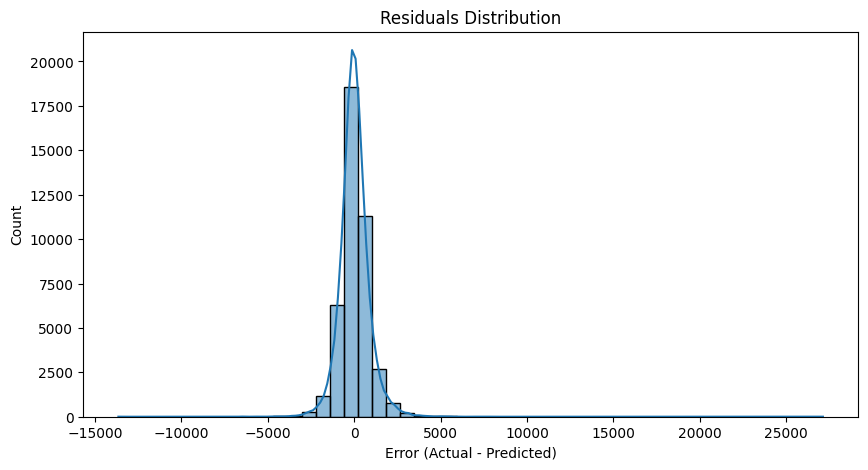


Top 5 Worst Predictions (High Error):
        Actual     Predicted         Error
676713   41551  14433.604492  27117.395508
216325   29161   9522.809570  19638.190430
652815   27330  11573.221680  15756.778320
676714   30038  14916.661133  15121.338867
676712   22882   8479.672852  14402.327148

>>> Phase 3 Completed Successfully.


In [11]:
# ------------------------------------------
# 4. Error Analysis
# ------------------------------------------
print("\n[4] Performing Error Analysis...")

analysis_df = X_test.copy()
analysis_df['Actual'] = y_test
analysis_df['Predicted'] = y_pred_xgb
analysis_df['Error'] = analysis_df['Actual'] - analysis_df['Predicted']
analysis_df['Abs_Error'] = analysis_df['Error'].abs()

# Plot Residuals
plt.figure(figsize=(10, 5))
sns.histplot(analysis_df['Error'], bins=50, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Error (Actual - Predicted)")
plt.savefig("Residuals_Distribution.png")
plt.show()

# Top 5 Worst Predictions
print("\nTop 5 Worst Predictions (High Error):")
print(analysis_df.nlargest(5, 'Abs_Error')[['Actual', 'Predicted', 'Error']])
